# Problem Set 1

CHEM 5501 - Advanced Topics in Physical Chemistry

(9/2/26)

# 1.1C

The resulting equation from 1.1a leaves us with:

$\ln(\frac{t_f(T)}{t_0}) \approx \frac{E_a}{R}(\frac{1}{T}-\frac{1}{T_0})$ 


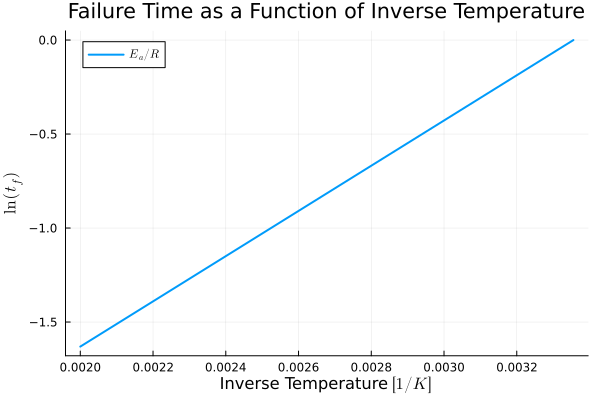

In [ ]:
using Plots
gr() 

# Generate data
temp_range = range(298, 500, length=100) #Range from room teperature to 500K
inverse_temp_range = (temp_range).^-1

Ea = 10000 # J
R = 8.314462618 # J/mol k
T_0 = 298

y = (Ea/R).*((inverse_temp_range).-(1/T_0))

plot(
    inverse_temp_range, 
    y, 
    label=raw"$E_a / R$", 
    lw=2, 
    title="Failure Time as a Function of Inverse Temperature", 
    xlabel=raw"Inverse Temperature $[1/K]$", 
    ylabel=raw"$\ln(t_f)$"
)


# 1.4

$[\text{CO}_2] = P_{\text{CO}_2} k_H$

# 1.4a

In [21]:
using CSV
using DataFrames

file_path = joinpath(@__DIR__, "data_henrys.txt") # Gets around some error with my file tree even though I was using relative paths

df = CSV.read(file_path, DataFrame, delim=' ')

print(df)

8×2 DataFrame
 Row │ P[atm]   C[M]     
     │ Float64  Float64  
─────┼───────────────────
   1 │    0.68  0.02346
   2 │    1.36  0.051952
   3 │    2.04  0.081396
   4 │    2.72  0.103088
   5 │    3.4   0.12818
   6 │    4.08  0.143616
   7 │    4.76  0.165172
   8 │    5.1   0.18768

# 1.4b

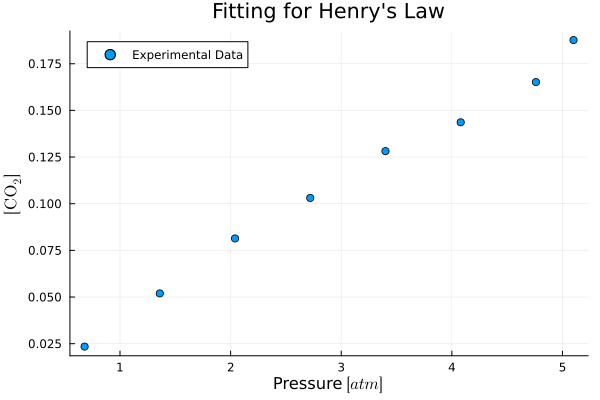

In [46]:
using Plots

gr() 

scatter(
    df[!, "P[atm]"], 
    df[!, "C[M]"],
    title="Fitting for Henry's Law", 
    label="Experimental Data",
    xlabel=raw"Pressure $[atm]$", 
    ylabel=raw"$[\mathrm{CO}_2]$"
)

# 1.4c and 1.4e for plot

$\chi^2(a_1,a_2,...a_n) = \sum\limits_{k=1}^N [y(x_k|a_1,a_2,...,a_N)-y_k]^2$

which by setting $a$ to $k_H$ for the slope, $x_k$ to $P_k$, and $y_k$ to $C_k$ we get:

$\chi^2(k_H) = \sum\limits_{k=1}^N [k_H P_k - C_k]^2$

which is then differentiated:

$\frac{\partial \chi^2}{\partial k_H} = \frac{\partial}{\partial k_H} \sum\limits_{k=1}^N [k_H P_k - C_k]^2 = 0$

by the following simplification steps:

$\sum\limits_{k=1}^N 2[k_H P_k - C_k] \cdot P_k= 0$

$\sum\limits_{k=1}^N [k_H P_k^2 - P_k C_k]= 0$

$\sum\limits_{k=1}^N [k_H P_k^2] - \sum\limits_{k=1}^N[P_k C_k]= 0$

$k_H \sum\limits_{k=1}^N [P_k^2] = \sum\limits_{k=1}^N[P_k C_k]$

which then leaves us:

$k_H = \frac{\sum\limits_{k=1}^N[P_k C_k]}{\sum\limits_{k=1}^N [P_k^2]}$


Experimentally Determined Henry's Law Constant (k_H): 0.036345477707006364
LSS Method Uncertainty (SE): 0.0005442639001983513


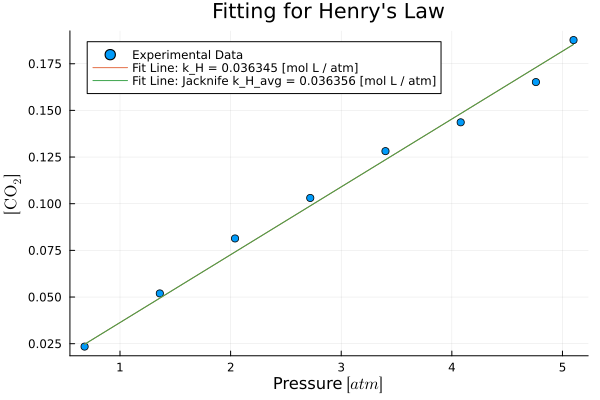

In [ ]:
using Plots

gr() 

numerator = sum(df[!, "P[atm]"] .* df[!, "C[M]"])

denominator = sum(df[!, "P[atm]"] .^ 2)

k_H = numerator / denominator

print("Experimentally Determined Henry's Law Constant (k_H): ", k_H)

P_range = range(minimum(df[!, "P[atm]"]), maximum(df[!, "P[atm]"]), length=100)
C_line = k_H .* P_range

C_pred = k_H .* df[!, "P[atm]"] # C_line but with same length as df

residuals = df[!, "C[M]"] .- C_pred

# Residual Sum of Squares (RSS) method
RSS = sum(residuals .^ 2)
DoF = length(df[!, "P[atm]"]) - 1
resid_var = RSS / DoF
se_k_H = sqrt(resid_var / denominator)

println("\nLSS Method Uncertainty (SE): ", se_k_H)

scatter(
    df[!, "P[atm]"], 
    df[!, "C[M]"],
    title="Fitting for Henry's Law", 
    label="Experimental Data",
    xlabel=raw"Pressure $[atm]$", 
    ylabel=raw"$[\mathrm{CO}_2]$"
)

plot!(
    P_range,
    C_line,
    label="Fit Line: k_H = $(round(k_H, digits=6)) [mol L / atm]", # LaTeX formatting was breaking here
)

plot!(
    P_range,
    C_line,
    label="Fit Line: Jacknife k_H_avg = $(round(k_H_avg, digits=6)) [mol L / atm]", # LaTeX formatting was breaking here
)

# 1.4.d

Error Formula: 

$ s.e. = \sqrt{\frac{n-1}{n}\sum_{i=1}^n (k_{H,i}-k_{H,avg})^2}$

In [83]:
n_rows = nrow(df)

indv_kh = []

for i in 1:n_rows
    rows_exclude_i = 1:n_rows .!= i
    loop_df = df[rows_exclude_i, :]

    numerator = sum(loop_df[!, "P[atm]"] .* loop_df[!, "C[M]"])
    denominator = sum(loop_df[!, "P[atm]"] .^ 2)
    k_H = numerator / denominator

    push!(indv_kh, k_H)
end

k_H_avg = sum(indv_kh) / n_rows

print("Jackknife Method Average (k_H,avg): ", k_H_avg)

uncert = sqrt(((n_rows - 1) / n_rows) * sum((indv_kh .- k_H_avg) .^ 2))

println("\nJackknife Method Uncertainty (SE): ", uncert)



Jackknife Method Average (k_H,avg): 0.03635629820216908
Jackknife Method Uncertainty (SE): 0.0006530265092940046


The average calculated and the uncertainty are both higher with the Jacknife method compared to LSS.